## Transforming from txt 3-mers to csv continious

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
def transform_dna_sequence(sequence):
    # Split sequence by spaces to get each triplet
    triplets = sequence.split()

    # Take the first character from the first triplet
    transformed_seq = triplets[0][0:3]

    # Concatenate with the last character of each subsequent triplet
    transformed_seq += "".join([triplet[-1] for triplet in triplets[1:]])

    return transformed_seq


def transform_methyl_sequence(sequence):
    return (
        "2" + sequence + "2"
    )  # 3mers were labeled for each mid-token, hence, padding orriginal sequence with 'unknown' metylation label for the first and last nucleotide

In [ ]:
root = "../Data/Raw/fig_2c"
dest = root.replace("Raw", "Curated")
for dir in os.listdir("../Data/Raw/fig_2c"):
    for data_type in ["data", "test_data"]:

        data = pd.read_csv(os.path.join(root, dir, f"{data_type}.txt"), sep="\t")
        data["input_ids"] = data["dna_seq"].apply(transform_dna_sequence)
        data["methylation_ids"] = data["methyl_seq"].apply(transform_methyl_sequence)
        data["label"] = [int(x == "T") for x in data["ctype"]]
        data = data[["input_ids", "methylation_ids", "label", "dmr_label"]]
        data.columns = ["input_ids", "methylation_ids", "label", "dmr_id"]

        data["label"] = np.array(data["label"], dtype=np.int8)
        outdir = os.path.join(dest, dir)
        if not os.path.exists(outdir):
            os.mkdir(outdir)
        if data_type == "data":
            data.to_csv(os.path.join(outdir, "train.csv"), index=False)
        else:
            data.to_csv(os.path.join(outdir, "test.csv"), index=False)
            data.to_csv(os.path.join(outdir, "dev.csv"), index=False)

## Methylation levels analysis

In [4]:
path_train = "../Data/Curated/MethylBERT_Figure3D_original/train.txt"
path_test = "../Data/Curated/MethylBERT_Figure3D_original/test.txt"
data = pd.concat([pd.read_csv(path_train, sep="\t"), pd.read_csv(path_test, sep="\t")])

In [5]:
data["methylated_cpgs"] = [x.count("1") for x in data["methyl_seq"]]
data["unmethylated_cpgs"] = [x.count("0") for x in data["methyl_seq"]]
data["total_cpgs"] = data["methylated_cpgs"] + data["unmethylated_cpgs"]
data["methylation_rate"] = data["methylated_cpgs"] / data["total_cpgs"]

In [6]:
data_agg = (
    data[["dmr_label", "ctype", "methylation_rate"]]
    .groupby(by=["dmr_label", "ctype"])
    .agg(
        methylation_rate_mean=pd.NamedAgg(column="methylation_rate", aggfunc="mean"),
        methylation_rate_sd=pd.NamedAgg(column="methylation_rate", aggfunc="std"),
    )
)

In [7]:
data["ctype"] = data["ctype"] == "T"
data["ctype"] = data["ctype"].astype("int")

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_filled_kde(
    values, groups, alpha=0.4, ax=None, bw_adjust=0.3, figsize=(10, 12)
):
    """
    Plots overlapping KDE (Kernel Density Estimation) curves with filled areas for two groups (0 and 1).
    Also computes Cohen's d to measure effect size.

    Parameters:
    - values: A list or numpy array of numerical values.
    - groups: A list or numpy array of group labels (0 or 1).
    - system_index: Index or name of the system being analyzed.
    - alpha: Transparency level for the filled area under KDE curves (default is 0.4).
    - ax: Matplotlib axis to plot on (optional).
    """
    # Convert to numpy arrays
    values = np.array(values)
    groups = np.array(groups)

    # Ensure groups contain only 0s and 1s
    unique_groups = np.unique(groups)
    if len(unique_groups) > 2 or set(unique_groups) - {0, 1}:
        raise ValueError("Groups should contain only 0 and 1.")

    # Separate values by group
    values_0 = values[groups == 0]  # Impostor scores
    values_1 = values[groups == 1]  # Genuine scores

    # Compute Uniquness and permanence
    uniqueness = np.abs(np.mean(values_0) - np.mean(values_1))

    n1, n2 = len(values_0), len(values_1)
    std1, std2 = np.std(values_0, ddof=1), np.std(values_1, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    # permanence = pooled_std

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # KDE plots with filled area
    sns.kdeplot(
        values_0,
        color="blue",
        fill=True,
        alpha=alpha,
        label="Normal",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )
    sns.kdeplot(
        values_1,
        color="red",
        fill=True,
        alpha=alpha,
        label="Tumor",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )

    # Labels and legend
    ax.set_xlabel("Methylation level", fontsize=20)
    ax.set_ylabel("Density", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # ax.set_title(f"DLBCL reads methylation levels for \n top-100 DMRs used in MethylBERT paper",fontsize=20)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend(fontsize=20)

    # If ax is None, show the plot
    if ax is None:
        plt.show()

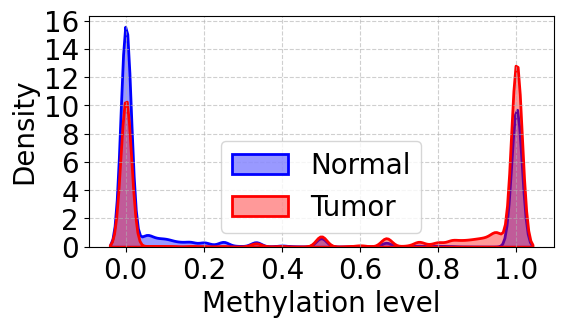

In [21]:
plot_filled_kde(
    data["methylation_rate"], data["ctype"], alpha=0.4, bw_adjust=0.2, figsize=(6, 3)
)